
# <span style="color:rgb(213,80,0)">Evlaución de las capacidades de robot Scara</span>

Diego Esteban Arango Arroyo

## Resumen

En este documento se aborda la planeación de trayectorias para un robot SCARA de tres eslabones (L₁=0.5 m, L₂=0.5 m, L₃=0.3 m). Se plantea una tarea concreta: mover el efector final desde una posición inicial (x=0.6, y=0.5, θ=0) hasta una posición final (x=0.6, y=−0.5, θ=−π/4). El análisis se estructura en torno a dos perspectivas de planeación: en el espacio de las juntas, donde se interpolan directamente los ángulos articulares, y en el espacio de trabajo, donde se interpola sobre las coordenadas cartesianas del efector. Para ambos enfoques se utiliza un polinomio quíntico λ(t) = 10(t/t_f)³ − 15(t/t_f)⁴ + 6(t/t_f)⁵, que satisface seis condiciones de contorno (posición, velocidad y aceleración iguales a cero en los extremos), garantizando así un perfil de movimiento suave. En el espacio de las juntas la cinemática inversa se calcula solo para la postura inicial y final; en el espacio de trabajo se recalcula en cada uno de los 11 puntos discretos de la trayectoria mediante el método geométrico, lo que asegura que el efector describa una línea recta en el plano cartesiano.

También, se obtienen las velocidades articulares derivando el polinomio quíntico, resultando en un perfil de campana, y las aceleraciones derivándolo una vez más, produciendo perfiles bimodales que confirman el arranque y la parada suaves. Se observa que la junta 3 presenta velocidades y aceleraciones inversas respecto a las otras juntas por efecto de la compensación simultánea del movimiento traslacional y de la rotación del efector. Adicionalmente, se evalúa la manipulabilidad w = |sin θ₂| a lo largo de la trayectoria: los valores oscilan entre 0.70 y 0.97, lo que indica que el robot opera siempre alejado de singularidades, siendo el punto de mínima manipulabilidad cerca de t=4 s, donde el brazo está más doblado, el instante que mayor exigencia impone al controlador. Finalmente, se calculan los pares dinámicos de las tres articulaciones aplicando la ecuación de Euler-Lagrange τ = M(q)q̈ + C(q,q̇)q̇ + G(q), incluyendo efectos de inercia, fuerzas centrípetas y de Coriolis, y se calcula la potencia instantánea como Pᵢ = τᵢ·q̇ᵢ. Los resultados muestran picos de torque y potencia en la fase central de la trayectoria, con transiciones suaves que validan la integridad mecánica del planificador.

Por último, se implementa un nodo controlador en Python 3 llamado xi_plan_py, en ROS 2, que publica en tiempo real los ángulos articulares calculados mediante cinemática inversa sobre el perfil quíntico del espacio de trabajo. Este nodo controla un robot SCARA simulado en Gazebo y visualizado en RViz, confirmando visualmente que el efector sigue la trayectoria rectilínea especificada. La comparación entre ambos enfoques de planeación corrobora que, si bien producen trayectorias articulares distintas para la misma tarea, el enfoque en el espacio de trabajo garantiza una geometría cartesiana predecible (línea recta), mientras que el enfoque articular resulta computacionalmente más ligero pero impredecible en el espacio físico.

## Defición de la tarea

El robot debe lleva su efector final de un punto a otro, sin embargo, en este documento se analizarán dos perspectivas para darle la instrucción al robot y que cumpla con dicha tarea.


La primera perspectiva es la del espacio de las juntas, cuando se define la tarea desde el espacio de las juntas las variables son los ángulos articulares q ( $\theta_1 ,\theta_2 \;y\;\theta_3$ ), o las orientaciones de las juntas. A esta perspectiva se le podría llamar


In [ ]:
% Definicion de los puntos
% Pose inicial
x_in = 0.6;
y_in = 0.5;
theta_in = 0;
% Pose final
x_fin = 0.6;
y_fin = -0.5;
theta_fin = -pi/4;

### Definición de la tarea en el espacio de las juntas

Hacer que un robot lleva a cabo una tarea en el espacio de las juntas conlleva definir y controlar su movimiento especificándole la posición, velocidad y aceleración de cada una de sus articulaciones. Este enfoque facilita el control de los motores y permite tener bajo control la integridad mecánica del robot, puesto que el único objetivo es llevar al efector final de un punto a otro, sin preocuparse por el movimiento que realizará; lo que la convierte en una adición indirecta de la suma de los movimientos articulares definidos.


Para clacular la planeación de movimientos en el espacio de las juntas se requiere hacer el cálculo de la postura en punto inicial y en punto final. De esta manera, la instrucción que se le da al robot es simplemente cambar su postura de un estado a otro, lo que reduce el costo computacional que se requiere para controlar al robot.


Este enfoque no se preocupa por el movimiento que tendrá el robot entre el punto A y el punto B, o punto inicial y punto final; la ruta que el efector final traza durante el cambio de estado no es conocida antes de hacer los cálculos; en lo que realmente se presta atención es en la capacidad de cada junta del robot para realizar el cambio de estado individual (es decir, cada junta pasa de tener una condición $q_{n_0 }$ a una condición $q_{n_1 }$ ), pero coordinado, de cada una de ellas. Así, la suma de la orientación de cada articulación logra una configuración específica que alcanza la postura final del efector. Por lo tanto, si tenemos una postura inicial $q_0$ en un punto $A$


$$q_0 =\left\lbrack \begin{array}{c} q_{1_0 } \newline \vdots \newline q_{n_0 }  \end{array}\right\rbrack$$

y queremos que el robot adopte una postura final $q_1$ en un punto $B$,


$$q_1 =\left\lbrack \begin{array}{c} q_{1_1 } \newline \vdots \newline q_{n_1 }  \end{array}\right\rbrack$$

entonces la expresión que nos permite este cambio de las juntas es


$$q=\left\lbrack \begin{array}{c} q_{1_0 +\lambda \left(t\right)\cdot \left(q_{1_1 } -q_{1_0 } \right)} \newline \vdots \newline q_{n_0 +\lambda \left(t\right)\cdot \left(q_{1_1 } -q_{1_0 } \right)}  \end{array}\right\rbrack$$

Como se puede observar, es neceario conocer el la orientación de la junta en la posición inicial y en la posición final, para esto se realiza el cálculo de la primera postura, o postura inicial, se utiliza la cinemática inversa de la posición. Como primer paso se calcula la posición de la muñeca, o articulación, del eslabón 3


$$q\left(x,y\right)=q_0 \left(x_{\textrm{in}} ,y_{\textrm{in}} \right)+L_3 \left\lbrack \begin{array}{c} \cos \theta_{\textrm{in}} \newline \textrm{sen}\theta_{\textrm{in}}  \end{array}\right\rbrack$$

y posteriormente, calcular la orientación de la articulación 2 por ley de cosenos


$$x_{\textrm{in}}^2 +y_{\textrm{in}}^2 =L_1^2 +L_2^2 +2L_1 L_2 \cos \theta_{2_{\textrm{in}} }$$

Despejando:


$$\theta_{2\textrm{in}} =\textrm{arcsen}\left(\frac{x_{\textrm{in}}^2 +y_{\textrm{in}}^2 -L_1^2 +L_2^2 }{2L_1 L_2 }\right)$$

In [ ]:
% Cálculo de la solución de la primera postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.3; % Longitud del tercer eslabón

% Planteamiento de la solucion

x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);

% Solucion por el metodo geometrico

theta_2_in = acos((x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2))

theta_2_in = 1.8965



Para la orientación de la primera articulación, descomponemos el ángulo hacia la muñeca en dos partes usando el triángulo formado, como se muestra en figura 1, el ángulo $\beta$ (en la figura es el ángulo B) es el ángulo del vector que va hacia la muñeca


$$\beta =\textrm{atan2}\left(x_3 ,y_3 \right)$$

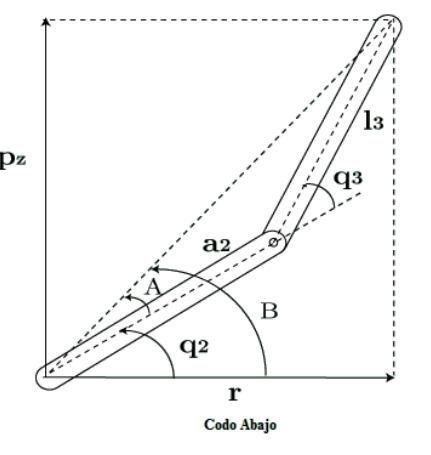


Figura 1. Orientación del segundo eslabón por el método geométrico.


El ángulo $\psi$ (en la figura 1 es el ángulo A) es el ángulo formado entre el esalbón uno y el vector que va hacia la muñeca, al cual lo podemos definir como


$$\psi =\textrm{arcsen}\left(\frac{x_{\textrm{in}}^2 +y_{\textrm{in}}^2 -L_1^2 +L_2^2 }{2L_1 \sqrt{x_{\textrm{in}}^2 +y_{\textrm{in}}^2 }}\right)$$

Conociendo estos ángulos, existen dos soluciones para el robot


$$\theta_{1_{\textrm{in}} } =\beta -\psi$$

y


$$\theta_{1_{\textrm{in}} } =\beta +\psi$$

según la configuración del codo del robot, es decir, si la segunda articulación se encuentra en una coordenada ${}^Oy_2>{}^Oy_3$ se utiliza la primera solución. Por el contrario, si la segunda articulación se encuentra en una coordenada ${}^Oy_2<{}^Oy_3$ se usa la segunda solución.


In [ ]:
beta = atan2(y_3,x_3);

psi = acos((x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2)));

% theta_1_in = beta + psi

 theta_1_in = beta - psi

theta_1_in = 0.0821



Y por útimo, ya que la orientación del efector es la suma de los 3 ángulos articulares


$$\theta_{\textrm{in}} =\theta_{1_{\textrm{in}} } +\theta_{2_{\textrm{in}} } +\theta_{3_{\textrm{in}} }$$

Despejando, se obtiene la orientación de la junta 3


$$\theta_{3_{\textrm{in}} } =\theta_{\textrm{in}} -\theta_{1_{\textrm{in}} } -\theta_{2_{\textrm{in}} }$$

In [ ]:

% theta_1_in = beta - psi

theta_3_in = theta_in -theta_1_in - theta_2_in

theta_3_in = -1.9786



Para obtener el segundo punto, o punto final, se replica la obtención de la cinemática inversa de la posición con las coordanas del punto al que se desea llevar o posicionar el efector final del robot


$$q\left(x,y\right)=q_1 \left(x_{\textrm{fin}} ,y_{\textrm{fin}} \right)+L_3 \left\lbrack \begin{array}{c} \cos \theta_{\textrm{fin}} \newline \textrm{sen}\theta_{\textrm{fin}}  \end{array}\right\rbrack$$

In [ ]:
%% Solucion para el punto final

x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);

% Solucion por le metodo geometrico

theta_2_fin = acos((x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2))

theta_2_fin = 2.1334

In [ ]:

beta = atan2(y_3,x_3);

psi = acos((x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2)));

% theta_1_fin = beta + psi

theta_1_fin = beta - psi

theta_1_fin = -1.7052

In [ ]:

theta_3_fin = theta_fin -theta_1_fin - theta_2_fin

theta_3_fin = -1.2136


## Plateamiento de una trayectoria en el espacio de las juntas del robot

Conociendo la configuración articular del robot en la posición incial y final del efector, se puede dar la instrucción de seguir una trayectoria para controlar el movimiento del robot entre los puntos A y B. Mediante una serie de puntos intermedios, se define la trayectoria como un cambio en la orientación de cada articulación entre cada punto de la trayectoria, es decir, se debe calcular las orientaciones individuales de las articulaciones a partir de las coordedas y orientación a la que deberá llegar el efector en cada uno de los puntos de la trayectoria, para conseguir una configuración específica cada vez.


Para definir la trayectoria que deberá seguir el efector, usamos la expresión


$$q =q_i +\lambda \left(t\right)\left(q_{\textrm{fin}} -q_{\textrm{in}} \right)$$

donde $\lambda \left(t\right)$ es un polinomio de orden 5, esto se debe a las condiciones, o variables, que describen el comportamiento del movimiento del robot. Un polinomio de orden $n$, es capaz de describir $n+1$ variables, para el robot scara, se tienen las siguientes variables o condiciones:


 $q\left(0\right)=q_i$, es la posición inicial del efector;


 $\dot{q} \left(0\right)=0$, es la velocidad inicial del efector;


 $\ddot{q} \left(0\right)=0$, es la aceleración incial del efector;


 $q\left(t_f \right)=q_f$, es la posición del efector en el tiempo final;


 $\dot{q} \left(t_f \right)=0$, es la velocidad del efector en el tiempo final;


 $\ddot{q} \left(t_f \right)=0$, es la aceleración del efector en el tiempo final.


Ya que se necesita satisfacer a 6 condiciones, el polinomio se propone de manera general como un polinomio quíntico que describa la posición del efector en el tiempo 0


$$\lambda \left(0\right)=a_0 +a_1 t+a_2 t^2 +a_3 t^3 +a_4 t^4 +a_5 t^5 =0$$

además, hacemos la derivada y la doble derivada para describir la velocidad y aceleración en el tiempo 0


$$\dot{\lambda} \left(0\right)=a_1 +{2a}_2 t+{3a}_3 t^2 +{4a}_4 t^3 +{5a}_5 t^4 =0$$

$$\ddot{\lambda} \left(0\right)={2a}_2 +{6a}_3 t+{12a}_4 t^2 +{20a}_5 t^3 =0$$

De la misma forma, obtenemos los polinomios para las condiciones del robot scara en el tiempo final


$$\lambda \left(t_f \right)=a_0 +a_1 t_f +a_2 t_f^2 +a_3 t_f^3 +a_4 t_f^4 +a_5 t_f^5 =0$$

$$\dot{\lambda} \left(t_f \right)=a_1 +{2a}_2 t_f +{3a}_3 t_f^2 +{4a}_4 t_f^3 +{5a}_5 t_f^4 =0$$

$$\ddot{\lambda} \left(t_f \right)={2a}_2 +{6a}_3 t_f +{12a}_4 t_f^2 +{20a}_5 t_f^3 =0$$

Evaluando los polinomios con sus respectivas condiciones y normalizando el incremento del tiempo para describir el cambio de posición a un incremento constante de punto a punto, la forma de la expresión del cambio en la configuración del robot es


$$q=q_i +\left(10\frac{t^{3/} }{t_f^3 }+15\frac{t^4 }{t_f^4 }+6\frac{t^5 }{t_f^5 }\right)\left(q_{\textrm{fin}} -q_{\textrm{in}} \right)$$

Para este caso, se consideró un tiempo final de 10 s, y mediante un ciclo for cuyo incremento es $t=i-1$ considerando que se harán 11 iteraciones para comenzar en tiempo 0 y terminar en tiempo 10; así conseguimos el valor de la orientación del efector en cada punto de la trayectoria.


In [ ]:
tf = 10;
tsim = 0:1:tf

tsim = 1x11
     0     1     2     3     4     5     6     7     8     9    10

In [ ]:
for i=1:tf+1
    t = i-1; % Increment time for the next iteration
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end

In [ ]:
theta_1_P

theta_1_P = 1x11
    0.0821    0.0668   -0.0214   -0.2094   -0.4852   -0.8115   -1.1378   -1.4137   -1.6017   -1.6899   -1.7052


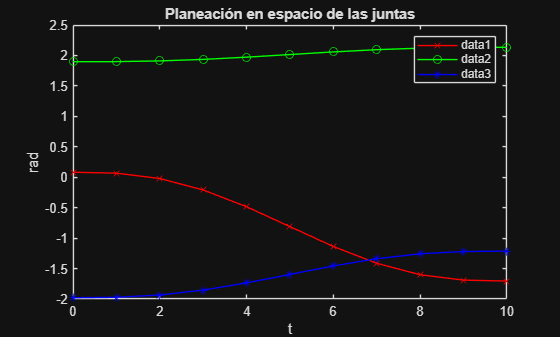

In [ ]:
figure;

plot(tsim, theta_1_P, 'r-x');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-*');

hold off;

legend
title("Planeación en espacio de las juntas")
xlabel("t")
ylabel("rad")


La gráfica muestra las orientaciones en radianes de cada una de las juntas, o articulaciones, del robot scara en cada punto de la trayectoria.


La junta 1 se mueve de 0 \[rad\] hasta \-1.75 \[rad\] aproximadamente. Es la junta que más se mueve, con un desplazamiento total de casi 1.75 \[rad\]. La curva tiene una forma de S, la cual es característica de un polinomio quíntico: empieza con pendiente casi cero, acelera hacia la mitad del recorrido y vuelve a suavizarse al final. Esto confirma que la velocidad y la aceleración son cero al inicio y al final.


La junta 2 va de 1.9 \[rad\] hasta 2.3 \[rad\] aproximadamente. Es la junta que menos se mueve, con un desplazamiento de aproximadamente 0.4 \[rad\]. Su curva también tiene forma de S pero mucho más plana, casi lineal a simple vista, lo cual tiene sentido porque cuando el desplazamiento $\Delta q$ es pequeño el perfil quíntico luce casi recto.


En el caso de la junta 3, se mueve desde \-2 \[rad\] hasta \-1.25 \[rad\] aproximadamente. Su desplazamiento es de aproximadamente 0.75 \[rad\]. Su forma de S es clara, con la distinción de que la curva sube a diferencia de la junta 1 que baja. Esto indica que la junta 3 rota en sentido opuesto a la junta 1 para mantener la orientación del efector final.

## Planeación de trayectoria en el espacio de trabajo del robot

Cuando se planea una trayectoria en el espacio articular, se interpola directamente entre los ángulos inicial y final de cada junta usando el polinomio quíntico, lo que conlleva un problema: la trayectoria que describe el efector final en el espacio cartesiano es completamente impredecible, una curva arbitraria que depende de la geometría del robot. En cambio, cuando se planea en el espacio de trabajo, se decide primero cómo se mueve el efector en el espacio y luego se calcula la cinemática inversa en cada instante para saber cuál debe ser la orientación de cada junta para alcanzar esa configuración.


Los pasos son similares, la diferencia es que primero se evalúa el polinomio quíntico directamente sobre las coordenadas del efector en el espacio, por lo que la expresión se modifica de la siguiente manera


$$p\left(t\right)=p_i +\lambda \left(t\right)\left(p_{\textrm{fin}} -p_{\textrm{in}} \right)$$

donde la función del tiempo con el incremento es


$$p\left(t\right)=p_i +\left(10\frac{t^3 }{t_f^3 }+15\frac{t^4 }{t_f^4 }+6\frac{t^5 }{t_f^5 }\right)\left(p_{\textrm{fin}} -p_{\textrm{in}} \right)$$


También, en este caso se resuelve la cinemática inversa de la posición dentro del ciclo for, lo que hace que se calcule en cada instante, o en cada punto, de la trayectoria, garantizando que el conjunto de orientaciones de las juntas describan las configuraciones específicas para que el efector del robot siga la trayectoria definida, en este caso, como una línea recta.



In [ ]:
% Cálculo de la solución de la primer postura

% Definición de los parámetros del robot
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.25; % Longitud del tercer eslabón

x_in = 0.6;
y_in = 0.5;
theta_in = 0;
% Pose final
x_fin = 0.6;
y_fin = -0.5;
theta_fin = -pi/4;
tf = 10;

for i=1:tf+1
    t = i;
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);

    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));

    % Solucion por le metodo geometrico

    theta_2_tray(i) = acos((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));

    beta = atan2(y_3_a(i),x_3_a(i));

    psi = acos((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));

    theta_1_tray(i) = beta + psi;

    theta_1_in = beta - psi;

    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);

end


In [ ]:
tsim=0:1:tf

tsim = 1x11
     0     1     2     3     4     5     6     7     8     9    10


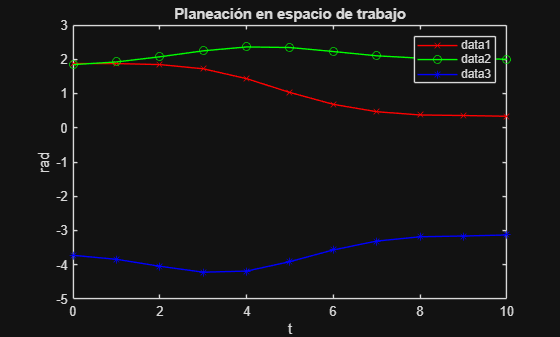

In [ ]:
figure;

plot(tsim, theta_1_tray, 'r-x');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');

hold off;

legend
title("Planeación en espacio de trabajo")
xlabel("t")
ylabel("rad")


La gráfica muestra las trayectorias articulares $\theta_1 \left(t\right),\theta_2 \left(t\right),\theta_3 \left(t\right),$ resultantes de aplicar cinemática inversa a lo largo de la trayectoria definida. A primera vista se parece a la gráfica del espacio articular, pero hay diferencias relevantes:


La junta 1 recorre desde 2 \[rad\] hasta 0.3 \[rad\] aproximadamente. Su desplazamiento es de aproximadamente 1.7 \[rad\] en sentido negativo. La curva mantiene su forma suave característica del polinomio quíntico propagado por la cinemática inversa, con pendiente casi horizontal al inicio y al final, confirmando velocidad articular cero en los extremos.


La junta 2 se mueve pero regresa aproximadamente a su orientación inicial. El punto de la trayectoria en el que más se tuvo que mover fue en el tiempo 4 s aproximadamente, llegano hasta ~2.5 \[rad\].  sta junta se mueve más que en la solución anterior y la curva es casi lineal a simple vista porque el cambio es gradual y relativamente pequeño comparado con el rango completo.


La jutnta 3 tiene un comportamiento peculiar, pues cambia de sentido de giro a mitad de trayectoria. El hecho de que la curva azul no conserve el mismo sentido de giro durante todo su desplazamiento ocurre porque $\theta_3$ � debe compensar simultáneamente dos efectos que no son lineales: los cambios de $\theta_1$ y $\theta_2$ debidos al movimiento de traslación, y el cambio de $\theta \left(t\right)$ debido a la rotación del efector. Cuando estos dos efectos se contraponen y uno domina al otro en diferentes fases del movimiento, la junta 3 invierte su dirección.



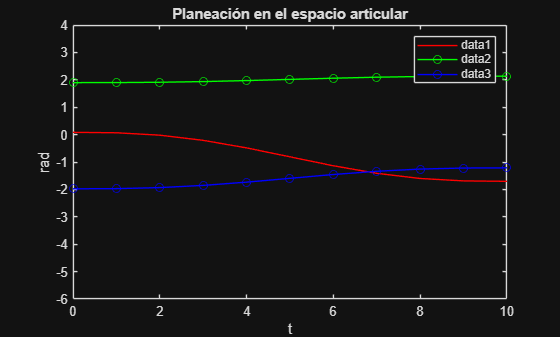

In [ ]:
figure;

plot(tsim, theta_1_P, 'r-');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-o');

hold off;

xlim([0.00 10.00])
ylim([-6.0 4.0])
legend
title("Planeación en el espacio articular")
xlabel("t")
ylabel("rad")

In [ ]:

% w = L1*L2*sin(theta_2)

## Calculo de la cinemática de velocidades del robot
### Cinemática de velocidades en espacio de las juntas

Para determinar las velocidades de las articulaciones en el espacio de las juntas retomamos la expresión


$$q\left(t\right)=q_i +\left(10\frac{t^{3/} }{t_f^3 }+15\frac{t^4 }{t_f^4 }+6\frac{t^5 }{t_f^5 }\right)\left(q_{\textrm{fin}} -q_{\textrm{in}} \right)$$

Sin embargo, derivamos la expresión  para conseguir las velocidades, resultando en la siguiente ecuación


$$\dot{q} \left(t\right)=\left(30\frac{t^{3/} }{t_f^3 }+60\frac{t^4 }{t_f^4 }+30\frac{t^5 }{t_f^5 }\right)\left(q_{\textrm{fin}} -q_{\textrm{in}} \right)$$

Al igual que con las orientaciones, e deben calcular las velocidades individuales de las articulaciones a partir de las coordedas y orientación a las que llega el efector en cada uno de los puntos de la trayectoria, para conseguir un incremento de velocidad gradual. Para esto, nuevamente se aplica el ciclo for sobre la derivada de la ecuación de $\dot{q}$



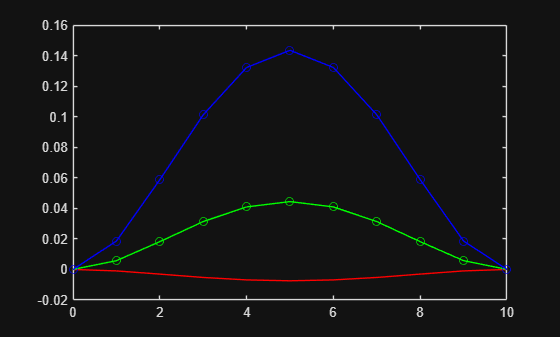

In [ ]:
tf = 10;


for i=1:tf+1
    t = i-1; % Increment time for the next iteration
    theta_1_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) =  ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);

end

figure;

plot(tsim, theta_1_P_v, 'r-');
hold on;
plot(tsim, theta_2_P_v, 'g-o');
plot(tsim, theta_3_P_v, 'b-o');

hold off;


La gráfica resultante muestra tres curvas que comienzan en una posición inicial y terminan en una posición final tras 10 segundos.


Se puede apreciar cómo la junta 1 parece moverse muy poco a muy baja velocidad y en sentido contrario a las demás. La junta 2 tiene una velocidad mayor, también se aprecia una aceleración y desaceleración graduales, justo como se explicaba que se busca que sean estos movimientos. Por otro lado, la junta 3 es la que más rápido se mueve, mostrando una aceleracipon y desaceleración más brusca, poco suave, esto se puede atribuir a la misma razón por la que en el análisis del movimiento era la única junta que giraba en sentido contrario, es una junta compensatoria, responde al efecto conjunto de las dos primeras y tiene que hacer las correcciones necesarias al mismo tiempo que se mueven las demás para obligar al efectro a seguir la trayectoria.

### Cinemática de velocidades en espacio de las juntas

Por último, para terminar con la descripción cinemática del movimiento del robot, se deriva una vez más la ecuación para obtener las velocidades. De igual forma, esta nueva expresión perteneciente a las aceleraciones se introduce en un ciclo for para calcular la aceleración de cada junta en cada punto de la trayectoria a seguir.


$$\ddot{q} \left(t\right)=\left(60\frac{t^{3/} }{t_f^3 }-180\frac{t^4 }{t_f^4 }+120\frac{t^5 }{t_f^5 }\right)\left(q_{\textrm{fin}} -q_{\textrm{in}} \right)$$


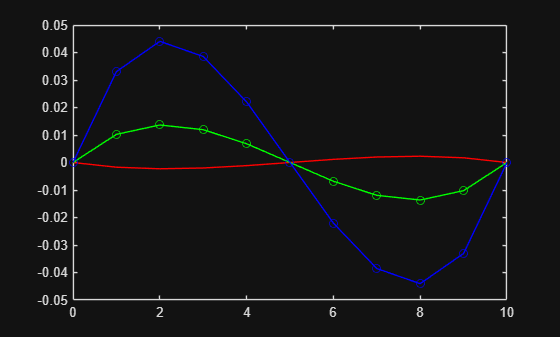

In [ ]:
tf = 10;

for i=1:tf+1
    t = i-1; % Increment time for the next iteration
    theta_1_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) =  ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);

end

figure;

plot(tsim, theta_1_P_a, 'r-');
hold on;
plot(tsim, theta_2_P_a, 'g-o');
plot(tsim, theta_3_P_a, 'b-o');

hold off;


Como era des esperarse, por el comportamiento de las velocidades en la gráfica anterior, las acelaraciones de las 3 juntas tienen sentidos positivos y negativos sin excepión. Nuevamente pueden apreciarse los dos fenómenos mencionados anterioremente: la junta 1 gira en sentido contrario a las demás y la junta 3 tiene aceleraciones significativamente mayores y menos graduales que las otras dos.

### Cinemática de velocidades en espacio de trabajo

Para el caso de las velocidades en el espacio de trabajo del robot, se utilizan nuevamente las ecuaciones con los polinomios quínticos derivados, pero a diferencia del primera cálculo, y de manera análoga a la cinemática de las posiciones, dentro del ciclo for se hace el cálculo de las velocidades inversas para cada instante, o punto, de la trayectoria definida



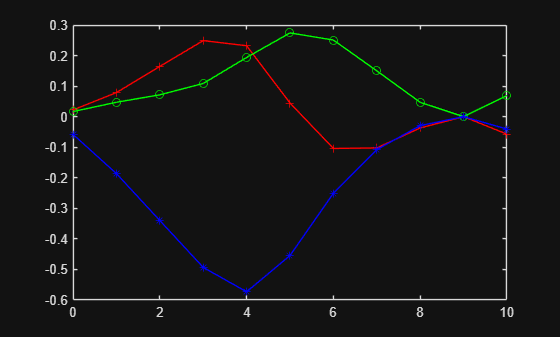

In [ ]:
% Cálculo de la solución de la primer postura

% Definición de los parámetros del robot
L_1 = 0.5; % Longitud del primer eslabón
L_2 = 0.5; % Longitud del segundo eslabón
L_3 = 0.25; % Longitud del tercer eslabón

% x_in = 0.3;
% y_in = 0.3;
% theta_in = 0;

% x_fin = 0.3;
% y_fin = -0.3;
%theta_fin = pi/2;

tf = 10;
for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);

    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);

    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L_1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L_1*sin(theta_1_2)) + (L_3*theta_dot_P*sin(theta_2_3))/(L_1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L_2*cos(theta_1_2 + theta_O_1) + L_1*cos(theta_O_1)))/(L_1*L_2*sin(theta_1_2)) - (y_dot*(L_2*sin(theta_1_2 + theta_O_1) + L_1*sin(theta_O_1)))/(L_1*L_2*sin(theta_1_2)) - (L_3*theta_dot_P*(L_1*sin(theta_1_2 + theta_2_3) + L_2*sin(theta_2_3)))/(L_1*L_2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L_3*sin(theta_1_2 + theta_2_3) + L_2*sin(theta_1_2)))/(L_2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L_2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L_2*sin(theta_1_2));


end

figure;

plot(tsim, theta_1_v, 'r-+');
hold on;
plot(tsim, theta_2_v, 'g-o');
plot(tsim, theta_3_v, 'b-*');

hold off;


Esta gráfica representa la respuesta de velocidad angular de las tres articulaciones del robot en el espacio de las juntas. En ella se observan varios fenómenos críticos para el control del robot. En primer lugar, la gráfica muestra cómo las velocidades comienzan en cero, alcanzan valores pico hacia la mitad del intervalo y descienden nuevamente a cero, lo cual es la respuesta directa a la ley de movimiento de tipo polinomial que se usó. Esto significa que el efector del robot ejecuta un arranque suave y una parada controlada, minimizando los esfuerzos bruscos sobre los actuadores. La diferencia en las amplitudes de las curvas refleja cómo cada articulación debe contribuir de manera distinta al movimiento del efector final: mientras una articulación puede requerir un giro rápido, otra puede realizar un ajuste menor para compensar la geometría del brazo durante el desplazamiento en el plano.


La manipulabilidad es una medida escalar que indica qué tan lejos está el robot de una singularidad en un instante dado. Matemáticamente, la manipulabilidad se define a partir del Jacobiano J(q)J(q) J(q) del robot como


 $t=4$


Para un robot planar 2R con eslabones $L_1$ y $L_2$, el Jacobiano que relaciona las velocidades articulares con velocidades cartesianas en el efector es


$$J\left(q\right)=\left\lbrack \begin{array}{cc} -\left(L_1 \textrm{sen}\theta_1 +L_2 \textrm{sen}\left(\theta_1 +\theta_2 \right)\right) & -L_2 \textrm{sen}\left(\theta_1 +\theta_2 \right)\newline L_1 \cos \theta_1 +L_2 \cos \left(\theta_1 +\theta_2 \right) & L_2 \cos \left(\theta_1 +\theta_2 \right) \end{array}\right\rbrack$$

y su determinante es


$$t\left(J\right)=L_1 L_2 \cos \theta_1 \cdot \cos \left(\theta_1 +\theta_2 \right)+L_1 L_2 \textrm{sen}\left(\theta_1 \right)\cdot \textrm{sen}\left(\theta_1 +\theta_2 \right)-L_2^2$$

además, haciendo uso de la identidad trigonométrica $\cos \left(A-B\right)=\textrm{cosA}\cdot \textrm{cosB}+\textrm{senA}\cdot \textrm{senB}$ se puede simplificar factorizando


$$\det \left(J\right)=L_2 \left(L_1 \cos \theta_2 -L_2 \right)$$

y por último, tomando valor absoluto y normalizando por $L_1 L_2$


$$w\frac{L_1 L_2 |\textrm{sen}\theta_2 |}{L_1 L_2 }=|\textrm{sen}\;\theta_2 |$$

Cuando $w$ es grande, el robot tiene buena capacidad de movimiento en todas las direcciones. Cuando $w$ tiende a 0, el robot se aproxima a una singularidad, que es una configuración donde el Jacobiano pierde rango y el robot queda incapaz de moverse en alguna dirección del espacio de trabajo, o equivalentemente, donde se necesitan velocidades articulares infinitas para producir velocidades cartesianas finitas.



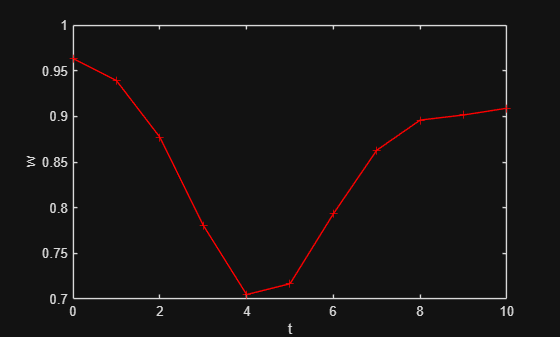

In [ ]:
for i=1:tf+1

    w(i) = L_1*L_2*sin(theta_2_tray(i))/(L1*L_2);

end

figure;
plot(tsim, w , 'r-+');

xlabel("t")
ylabel("w")


La manipulabilidad, según la gráfica, comienza en 0.96 y deciende hasta 0.7 aproximadamente, aunque al final recupera manipulabilidad alcanzando un valor de 0.91 aproximadamente. Esto implica que en ningún instante de la trayectoria el robot pierde capacidad de maniobra. Sin embargo, el punto de mínima manipulabilidad cerca de $t=4$ es donde el controlador deberá trabajar más duro para seguir la trayectoria con precisión, porque ahí el Jacobiano está más cercano a ser singular y pequeñas perturbaciones en el espacio articular producen errores más grandes en el espacio cartesiano.

## Evalaución de la capacidad del robot

 $$\begin{array}{l} \left(\begin{array}{c} {\ddot{\theta} }_{O,1} \,{\left(\frac{\cos \left(\theta_{1,2} \right)}{4}+\frac{{\sigma_{12} }^2 }{2}+\frac{{\sigma_{14} }^2 }{2}+\frac{27}{8}\right)}-{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{16} \,\sigma_{11} }{16}+\frac{\sigma_{12} \,\sigma_4 }{2}-\frac{\sigma_5 \,\sigma_{14} }{2}\right)}+{\ddot{\theta} }_{1,2} \,\sigma_3 +{\ddot{\theta} }_{2,3} \,\sigma_6 -{\dot{\theta} }_{1,2} \,{\left(\sigma_8 -\frac{\sigma_{14} \,\sigma_2 }{2}+\frac{\sigma_1 \,\sigma_{12} }{2}-\sigma_9 +\frac{{\dot{\theta} }_{1,2} \,\sin \left(\theta_{1,2} \right)}{8}+\frac{{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{4}\right)}\newline \frac{{{\dot{\theta} }_{O,1} }^2 \,\sin \left(\theta_{1,2} \right)}{8}-{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_5 }{2}+\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_4 }{2}-\frac{\sigma_{16} \,\sigma_{11} }{16}\right)}+{\ddot{\theta} }_{2,3} \,\sigma_7 +\frac{\sigma_{10} \,\sigma_1 }{2}+{\ddot{\theta} }_{O,1} \,\sigma_3 -\frac{\sigma_{11} \,\sigma_2 }{2}+{\ddot{\theta} }_{1,2} \,{\left(\frac{{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}}^2 }{2}+\frac{{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}}^2 }{2}+\frac{33}{16}\right)}-{\dot{\theta} }_{1,2} \,{\left(\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_1 }{2}-\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_2 }{2}+\sigma_8 -\sigma_9 +\frac{{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{8}\right)}+\frac{{\dot{\theta} }_{1,2} \,{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{8}\newline {\ddot{\theta} }_{2,3} \,{\left(\frac{{\sigma_{16} }^2 }{128}+\frac{{\sigma_{18} }^2 }{128}+1\right)}-\frac{\sigma_5 \,\sigma_{11} }{2}+{\ddot{\theta} }_{1,2} \,\sigma_7 -{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{18} \,\sigma_5 }{16}-\frac{\sigma_{16} \,\sigma_{11} }{16}+\frac{\sigma_{16} \,\sigma_4 }{16}\right)}+{\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{18} \,\sigma_2 }{16}-\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{16} \,\sigma_1 }{16}+\frac{\sigma_{16} \,\sigma_{11} }{16}\right)}+{\ddot{\theta} }_{O,1} \,\sigma_6 +\frac{\sigma_{10} \,\sigma_4 }{2} \end{array}\right)\\
\mathrm{}\\
\mathrm{where}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_1 =\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+\sigma_{15} +{\dot{\theta} }_{O,1} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_2 =\sigma_{13} +{\dot{\theta} }_{O,1} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_3 =\frac{\cos \left(\theta_{1,2} \right)}{8}+\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_{12} }{2}+\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_{14} }{2}+\frac{33}{16}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_4 =\frac{{\dot{\theta} }_{1,2} \,\sigma_{18} }{8}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+\frac{{\dot{\theta} }_{O,1} \,\sigma_{18} }{8}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_5 =\frac{{\dot{\theta} }_{1,2} \,\sigma_{16} }{8}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}+\frac{{\dot{\theta} }_{O,1} \,\sigma_{16} }{8}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_6 =\frac{\sigma_{16} \,\sigma_{12} }{16}+\frac{\sigma_{18} \,\sigma_{14} }{16}+1\\
\mathrm{}\\
\mathrm{\ \ }\sigma_7 =\frac{\sigma_{16} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}}{16}+\frac{\sigma_{18} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}}{16}+1\\
\mathrm{}\\
\mathrm{\ \ }\sigma_8 =\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_{10} }{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_9 =\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_{11} }{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{10} =\sigma_{13} +\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}+{\dot{\theta} }_{O,1} \,\sigma_{12} \\
\mathrm{}\\
\mathrm{\ \ }\sigma_{11} =\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+{\dot{\theta} }_{O,1} \,\sigma_{14} +\sigma_{15} \\
\mathrm{}\\
\mathrm{\ \ }\sigma_{12} =\frac{\sigma_{16} }{8}+\sigma_{17} +\frac{\cos \left(\theta_{O,1} \right)}{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{13} ={\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{14} =\frac{\sigma_{18} }{8}+\sigma_{19} +\frac{\sin \left(\theta_{O,1} \right)}{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{15} ={\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{16} =\cos \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{17} =\frac{\cos \left(\theta_{1,2} +\theta_{O,1} \right)}{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{18} =\sin \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{19} =\frac{\sin \left(\theta_{1,2} +\theta_{O,1} \right)}{2}
\end{array}$$

## Cálculo de los pares del robot

 Se calculan los torques (o pares) dinámicos necesarios para que el robot ejecute la trayectoria definida, incorporando los efectos de la inercia, las fuerzas centrípetas y las fuerzas de Coriolis, a diferencia de los cálculos anteriores donde se limitaban a análisis geométricos. En robótica, la dinámica de un manipulador se describe mediante la ecuación de Euler\-Lagrange, la cual establece la relación entre los torques aplicados en las articulaciones ( $\tau$ ) y el estado del robot


$$\tau =M\left(q\right)\ddot{q} +C\left(q,\dot{q} \right)\dot{q} +G\left(q\right)$$

Donde:


 $M\left(q\right)$, es la matriz de inercia;


 $C\left(q,\dot{q} \right)$, representan los términos que agrupan las fuerzas centrípetas y de Coreolis; y


 $G\left(q\right)$, es el vector de fuerzas gravitacionales.


El código mostrado a continuación resume el desglose analítico subsecuente de la derivación de las ecuaciones de energía cinética y potencial del sistema


$$\tau_i =\frac{\mathrm{d}}{\mathrm{d}t}\left(\frac{\partial }{\partial t}L\right)-\frac{\partial }{\partial q_i }L$$

Los torques calculados son una suma ponderada de los efectos dinmámicos descritos por las ecuaciones anteriores, los términos multiplicados por las aceleraciones articulares corresponden al producto $M\left(q\right)\ddot{q}$. Estos términos representan el torque necesario para vencer la inercia de los eslabones; es decir, la fuerza que requiere el motor para poner el eslabón en movimiento desde el reposo o para detenerlo. Por otro lado, los términos que involucran multiplicaciones con las velocidades corresonden a la matriz de Coreolis y fuerzas centrípetas ( $C\left(q,\dot{q} \right)\dot{q}$ ). Estos efectos surgen porque el robot es un sistema multivariable; cuando el eslabón 1 se mueve, genera fuerzas inerciales ficticias que afectan al eslabón 2 y al 3. Estos términos son cruciales para el control de precisión a altas velocidades.


Por último, la potencia mecánica instantánea necesaria en cada actuador se calcula como el producto escalar del torque por la velocidad angular


$$P_i =\tau_i \cdot \dot{q_i }$$

In [ ]:

for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);

    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);

    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);

    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);

    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);

    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;

    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);


end



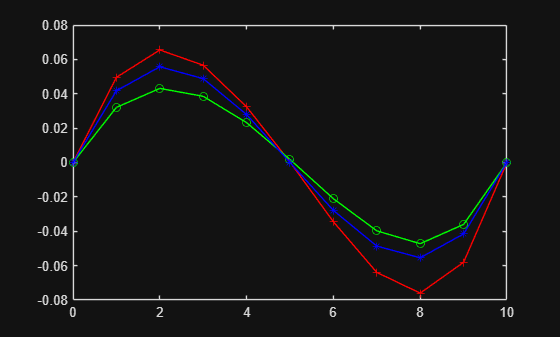

In [ ]:
figure;
plot(tsim, tao_1_c, 'r-+');
hold on;
plot(tsim, tao_2_c, 'g-o');
plot(tsim, tao_3_c, 'b-*');
hold off;


Se observa que el torque no es constante; exhibe una evolución temporal donde los picos de magnitud coinciden con las fases de máxima aceleración y desaceleración del manipulador. Físicamente, esto indica que los actuadores están luchando continuamente contra la inercia propia de los eslabones y contra los efectos de acoplamiento dinámico, donde el movimiento de una articulación induce fuerzas de reacción sobre las otras dos. La suavidad en la transición de estas curvas de torque es evidencia de un planificador de trayectorias que ha priorizado la integridad mecánica, evitando cambios bruscos que podrían excitar los modos de vibración de la estructura.



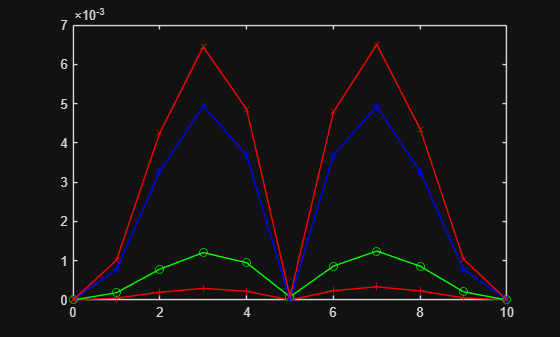

In [ ]:

figure;
plot(tsim, pot_1, 'r-+');
hold on;
plot(tsim, pot_2, 'g-o');
plot(tsim, pot_3, 'b-*');
plot(tsim, pot_total, 'r-x');
hold off;


Es gráfica ilustra el consumo de potencia, representa el costo energético del movimiento. La potencia total, que es la suma de los valores absolutos del producto del torque por la velocidad angular en cada articulación, presenta una forma de campana con picos pronunciados a mitad de la trayectoria. Estos puntos de máxima potencia coinciden con el instante en que el robot combina una alta velocidad angular con un torque considerable para vencer la inercia en la fase central del desplazamiento. El hecho de que la potencia caiga a cero en los extremos inicial y final de la gráfica confirma un estado de reposo absoluto, validando que el robot comienza y termina su tarea en equilibrio estático. La potencia es la suma de los trabajos individuales realizados contra la inercia, la gravedad y las fuerzas centrípetas; la forma suave y continua de la gráfica se debe a que el planificador de trayectoria ha evitado con éxito discontinuidades en el torque, garantizando que el consumo energético no presente picos aleatorios que pudieran comprometer la estabilidad del sistema o provocar fallos prematuros en los componentes de potencia.



## Simulación de una trayectoria desde el espacio de trabajo de un Robot Scara

Bajo los principios que ya se mencionaron anteriormente en el documento, se realizó un programa en Python 3 con un ciclo for que calcula la posición inversa del robot en cada punto de la trayectoria en línea recta. El nodo controlador, llamado "xi_plan_py", le da la instrucción de seguir una línea recta a un robot simulado en Gazebo, visualizado en rviz. A continuación se presenta la el código del nodo controlador del robot Scara "xi_plan_py"

```python

#!urs/bin/env python3

import rclpy
from rclpy.node import Node
from std_msgs.msg import Float64

import time
from math import cos, sin, atan2, acos, asin, sqrt, pow


class ScaraControl(Node):
    def __init__(self):
        super().__init__('xi_plan_node')

        self.pub_joint01_ = self.create_publisher(msg_type= Float64, 
                        topic='/joint1/cmd_pos',qos_profile= 10)
        
        self.pub_joint02_ = self.create_publisher(msg_type= Float64, 
                        topic='/joint2/cmd_pos',qos_profile= 10)
        
        self.pub_joint03_ = self.create_publisher(msg_type= Float64, 
                        topic='/joint3/cmd_pos',qos_profile= 10)
        
        self.timer_control_ = self.create_timer(timer_period_sec= 1.0, 
                        callback= self.cbck_scara_control)
        
        self.get_logger().info('Nodo controlador scara')


    def cbck_scara_control(self):

        # Definicion de las variables de la posicion inicial
        theta_1 = Float64()
        theta_2 = Float64()
        theta_3 = Float64()

        # Enviar comandos de la posicion inicial
        
        x_i = 0.6
        y_i = -0.5
        theta_i = 0

        x_j = 0.6
        y_j = 0.5
        theta_j = 0

        # theta_1_i, theta_2_i, theta_3_i = cin_inv(x_i, y_i, theta_i)

        # theta_1_j, theta_2_j, theta_3_j = cin_inv(x_j, y_j, theta_j)

        tf = 10 

        delta_t = 0
        #crear el arreglo del tiempo

        for i in range(1, 11):
            print('Intervalo de tiempo ' + str(i))
            #Porque la funcion del perfil f(t) solo es valida
            #en el rango de 0 a 1
            t_sim = delta_t/tf

            # theta_1_t = theta_1_i + (10*pow(t_sim,3)-15*pow(t_sim,4)+6*pow(t_sim,5)
            #                          )*(theta_1_j-theta_1_i)
            
            # theta_2_t = theta_2_j + (10*pow(t_sim,3)-15*pow(t_sim,4)+6*pow(t_sim,5)
            #                          )*(theta_2_j-theta_2_i)
            
            # theta_3_t = theta_3_i + (10*pow(t_sim,3)-15*pow(t_sim,4)+6*pow(t_sim,5)
            #                          )*(theta_3_j-theta_3_i)

            x_t = x_i+(10*pow(t_sim,3)-15*pow(t_sim,4)+6*pow(t_sim,5))*(x_j-x_i)
            y_t = y_i+(10*pow(t_sim,3)-15*pow(t_sim,4)+6*pow(t_sim,5))*(y_j-y_i)
            theta_t = theta_i+(10*pow(t_sim,3)-15*pow(t_sim,4)+6*pow(t_sim,5))*(theta_j-theta_i)
            
            theta_1_t, theta_2_t, theta_3_t = cin_inv(x_t, y_t, theta_t)

            theta_1.data = float(theta_1_t)
            self.pub_joint01_.publish(theta_1)
            theta_2.data = float(theta_2_t)
            self.pub_joint02_.publish(theta_2)
            theta_3.data = float(theta_3_t)
            self.pub_joint03_.publish(theta_3)

            delta_t = delta_t + 1
            time.sleep(0.5)


def cin_inv(x_in, y_in, theta_in):
    #Parametros del robot
    L_1 = 0.5
    L_2 = 0.5
    L_3 = 0.3

    x_3_in = x_in - L_3*cos(theta_in)
    y_3_in = y_in - L_3*sin(theta_in)

    theta_2_in = acos((pow(x_3_in,2)+ pow(y_3_in,2)-pow(L_1,2)-pow(L_2,2))/(2*L_1*L_2))

    beta = atan2(y_3_in, x_3_in)

    alpha = acos((pow(x_3_in,2)+pow(y_3_in,2)+pow(L_1,2)-pow(L_2,2))/(2*L_1*sqrt(pow(x_3_in,2)+pow(y_3_in,2))))

    theta_1_in = beta -alpha

    theta_3_in = theta_in -theta_1_in -theta_2_in

    return theta_1_in,theta_2_in,theta_3_in


def main(args= None):
    rclpy.init(args=args)
    node = ScaraControl()
    rclpy.spin(node)
    rclpy.shutdown()

if __name__ == '_main_':
    main()

```

Aunado al código, se presenta la simulación del robot Scara con su efector siguiendo una trayextoria de línea recta en el siguiente video

<div align = "center">

<video src="./videos/simulacion_xi_plan_py.mp4" controls width="100%"></video>

*Figura 2. Video de la simulación del robot scara siguiendo una trayectorira recta.*

</div>

## Conclusión

Se compararon los enfoques de planeación de trayectorias del robot Scara. Cuando se planea en el espacio de las juntas, el polinomio quíntico se aplica directamente sobre la orientación de las 3 juntas por separado, lo que produce trayectorias suaves y condicionadas. Sin embargo, la ruta que tiene el efector final del robot durante la trayectoria es completamente impredecible y arbitrariamente: el robot llega al destino correcto pero no garantiza ninguna forma geométrica particular en el camino. Por otro lado, cuando se planea en el espacio de trabajo, la interpolación quíntica se aplica directamente sobre las coordenadas cartesianas, y en cada instante se resuelve la cinemática inversa para obtener la configuración articular correspondiente. 

La comparación de las gráficas de ambos enfoques confirma que las trayectorias articulares resultantes son distintas incluso para la misma tarea, y que la solución con un comportamiento no monótono, lo que refleja que esta junta debe compensar simultáneamente el movimiento de traslación y la rotación del efector.

El análisis de manipulabilidad w=∣sinθ2​∣ a lo largo de la trayectoria demostró que el robot opera en todo momento lejos de sus singularidades, con valores entre 0.70 y 0.97. El mínimo cerca de t=4 coincide con el punto intermedio de la trayectoria donde el brazo está más doblado, y señala el instante donde el sistema de control deberá trabajar con mayor precisión. El hecho de que w nunca se acerque a cero valida que la tarea definida es completamente factible con la geometría del robot y los parámetros elegidos.

La implementación del nodo controlador "xi_plan_py" en ROS 2 complementó ampliamente el análisis de la planeación de trayectorias en los diferentes enfoques. El nodo replicó la lógica del espacio de trabajo: calculó la cinemática inversa en cada instante del perfil quíntico y publicó los ángulos articulares resultantes a los controladores de las juntas en Gazebo. La simulación confirmó visualmente que el efector sigue la trayectoria rectilínea especificada, validando que todo el análisis previo, desde la cinemática inversa hasta la planeación temporal.

## Referencias

- D. E. Flórez-Vergara, F. C. Castro-Riveros y R. A. Castillo-Estepa, "Planeación y ejecución de trayectorias en el espacio de trabajo para un robot Delta", vol. 25, no. 42, pp. 75 - 88. Marzo, 2016. Disponible en: https://doi.org/10.19053/01211129.4631
- B. Siciliano, L. Villanu, G. Oriolo y A. De Luca, "Foundations of Robotics", eBook, Springer, 2025. Disponible en: https://doi.org/10.1007/978-3-031-85523-8 